In [116]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten,BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam

In [117]:
train_data = os.listdir(r'C:\Users\Ashutosh Bhatt\deeplearning project\archive-3\train')
test_data = os.listdir(r'C:\Users\Ashutosh Bhatt\deeplearning project\archive-3\test')
print(train_data)
print(test_data)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [118]:
train_datagen = ImageDataGenerator(
    rescale=1./255,      # normalize pixel values
    rotation_range = 15,# rotate up to 30 
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    shear_range = 0.1,   # shear intensity (skew upto 30%)
    zoom_range = 0.3, # zoom in/out upto 30%
    horizontal_flip = True, # mirror the image
    fill_mode = 'nearest') # fills new empty pixer files


train_generator = train_datagen.flow_from_directory(
    r'C:\Users\Ashutosh Bhatt\deeplearning project\archive-3\train',
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    shuffle=True)
print(train_generator.class_indices)

Found 28709 images belonging to 7 classes.
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [119]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    r'C:\Users\Ashutosh Bhatt\deeplearning project\archive-3\test',
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    shuffle= False)

print(test_generator.class_indices)

Found 7178 images belonging to 7 classes.
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [55]:
classes = list(test_generator.class_indices.keys())


In [56]:
img , labels = train_generator.__next__()

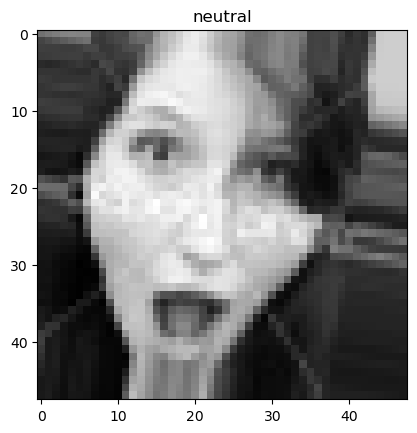

In [120]:
import random

i = random.randint(0,(img.shape[0])-1)
image = img[i]
label_name = classes[labels[i].argmax()]
plt.imshow(image[:,:,0],cmap='gray')
plt.title(label_name)
plt.show()            

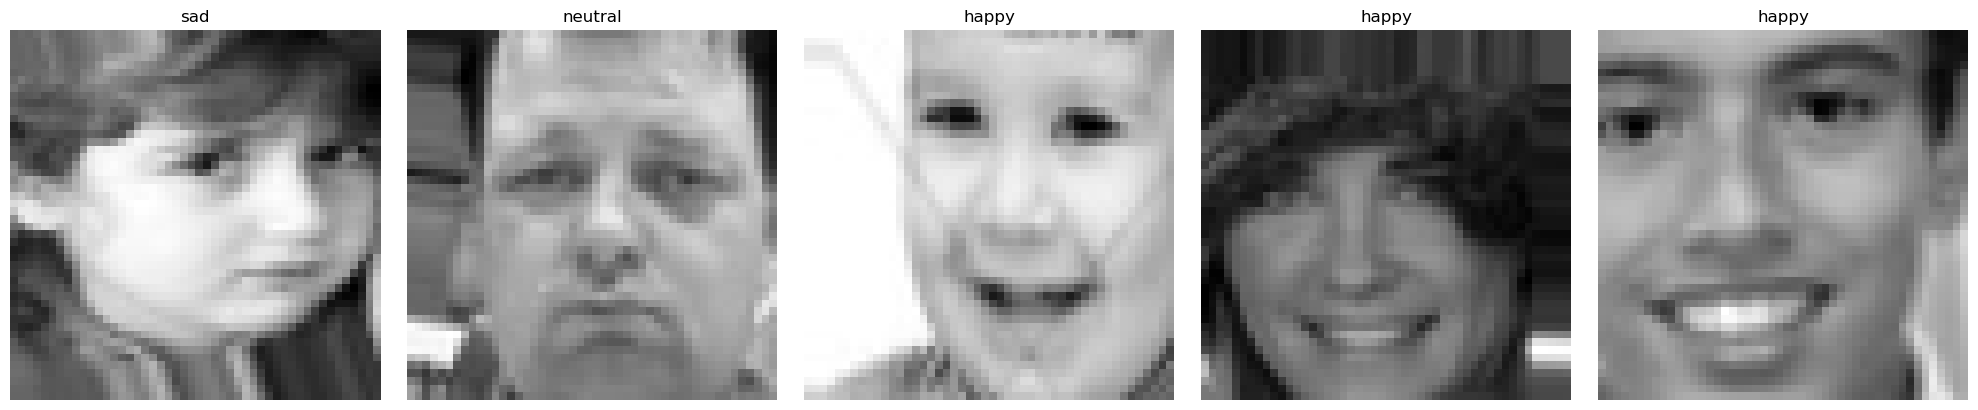

In [121]:
img, label = train_generator.__next__()

# Display a few images from the batch
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes = axes.flatten()

for i in range(5):
    ax = axes[i]
    ax.imshow(img[i].reshape(48, 48), cmap='gray')
    ax.set_title(classes[label[i].argmax()])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [122]:
cnn = Sequential()
cnn.add(Conv2D(32, (3, 3), activation='relu', padding = 'same',input_shape=(48,48,1)))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D((2, 2)))
#cnn.add(Dropout(0.25))

cnn.add(Conv2D(64, (3, 3), activation='relu',padding = 'same'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D((2, 2)))
cnn.add(Dropout(0.2))

cnn.add(Conv2D(128, (3, 3), activation='relu',padding = 'same'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D((2, 2)))
cnn.add(Dropout(0.3))

cnn.add(Conv2D(256, (3, 3), activation='relu',padding = 'same'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D((2, 2)))
cnn.add(Dropout(0.3))

cnn.add(Flatten())
cnn.add(Dense(512, activation='relu'))
cnn.add(Dropout(0.5))
cnn.add(Dense(7, activation='softmax'))

cnn.compile(optimizer= Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
print(cnn.summary())

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,573,511 (6.00 MB)

 Trainable params: 1,572,551 (6.00 MB)

 Non-trainable params: 960 (3.75 KB)

None


In [123]:
train_path =(r'C:\Users\Ashutosh Bhatt\deeplearning project\archive-3\train')
test_path = (r'C:\Users\Ashutosh Bhatt\deeplearning project\archive-3\test')

In [124]:

batch_size=32


num_train_imgs = 0
for root, dirs, files in os.walk(train_path):
    num_train_imgs += len(files)

num_test_imgs = 0
for root, dirs, files in os.walk(test_path):
    num_test_imgs += len(files)

print("Train images:", num_train_imgs)
print("Test images:", num_test_imgs)

Train images: 28709
Test images: 7178


In [131]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau ,ModelCheckpoint

# Define Early Stopping callback
early_stop = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience= 10,         # Number of epochs with no improvement after which training will be stopped.
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity.
    verbose =1 
)
reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.5,
    patience = 5,
    min_lr = 1e-6)

checkpoint = ModelCheckpoint(
    'best_emotio _model.keras',
    monitor = 'val_loss',
    save_best_only = True)
    

In [126]:
#from sklearn.utils.class_weight import compute_class_weight
# calculate weights based on your training labels
#class_weights = compute_class_weight(
    #class_weight = 'balanced',
    #classes = np.unique(train_generator.classes),
    #y=train_generator.classes)
#class_weight_dict = dict(enumerate(class_weights))

In [132]:
history = cnn.fit(
    train_generator,
    steps_per_epoch= num_train_imgs//batch_size,
    epochs=50,
    validation_data=test_generator,
    validation_steps=num_test_imgs//batch_size,
    callbacks=[early_stop,reduce_lr,checkpoint])
print("Training stopped at epoch:", len(history.history['loss']))

Epoch 1/50
897/897 ━━━━━━━━━━━━━━━━━━━━ 92s 103ms/step - accuracy: 0.5154 - loss: 1.2810 - val_accuracy: 0.5714 - val_loss: 1.1161 - learning_rate: 2.5000e-04
Epoch 2/50
897/897 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4688 - loss: 1.3314 - val_accuracy: 0.5705 - val_loss: 1.1180 - learning_rate: 2.5000e-04
Epoch 3/50
897/897 ━━━━━━━━━━━━━━━━━━━━ 96s 107ms/step - accuracy: 0.5187 - loss: 1.2738 - val_accuracy: 0.5612 - val_loss: 1.1448 - learning_rate: 2.5000e-04
Epoch 4/50
897/897 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.5000 - loss: 1.2684 - val_accuracy: 0.5607 - val_loss: 1.1460 - learning_rate: 2.5000e-04
Epoch 5/50
897/897 ━━━━━━━━━━━━━━━━━━━━ 98s 109ms/step - accuracy: 0.5201 - loss: 1.2703 - val_accuracy: 0.5766 - val_loss: 1.0930 - learning_rate: 2.5000e-04
Epoch 6/50
897/897 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4375 - loss: 1.2913 - val_accuracy: 0.5766 - val_loss: 1.0942 - learning_rate: 2.5000e-04
Epoch 7/50
897/897 ━━━━━━━━━━━━━━━━━━━━ 96s 107ms/ste

In [ ]:
  #class_weight = class_weight_dict,

###### cnn.save('Emotion_detection_model.h5')

In [133]:
print("Epochs actually run:", len(history.history['loss']))
print("Final train accuracy:", history.history['accuracy'][-1])
print("Final val accuracy:", history.history['val_accuracy'][-1])
print("Best val accuracy:", max(history.history['val_accuracy']))

Epochs actually run: 50
Final train accuracy: 0.6875
Final val accuracy: 0.5965401530265808
Best val accuracy: 0.5991908311843872


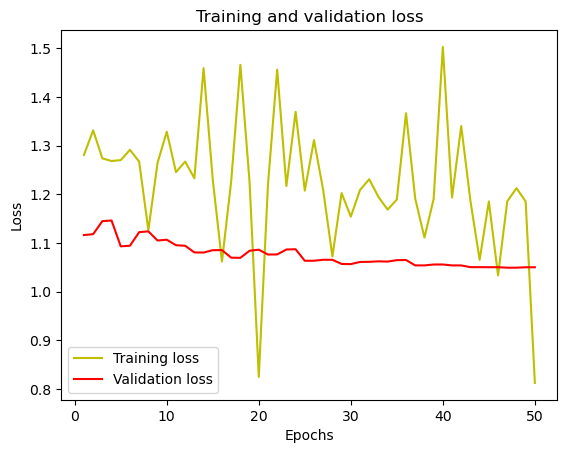

In [136]:
#plot the training and test loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) +1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

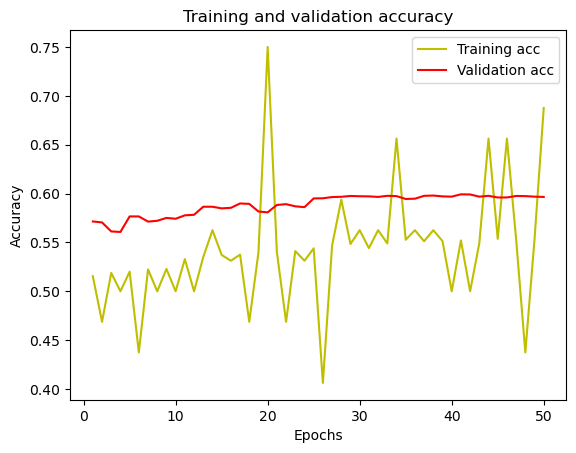

In [137]:
#plot the training and test accuracy at each
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [138]:
from keras.models import load_model
model = load_model('Emotion_detection_model.h5', compile = False)

# Generate a batch of test images
# Real accuracy over the FULL test set
test_loss, test_acc = cnn.evaluate(test_generator)
print("Full test accuracy:", test_acc)

# For a proper full-set confusion matrix, don't rely on __next__()
test_generator.reset()
predictions = np.argmax(cnn.predict(test_generator),axis=1)
test_labels = test_generator.classes



225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.5981 - loss: 1.0478
Full test accuracy: 0.5980774760246277
225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step


In [139]:
from sklearn import metrics
print("Accuracy = ", metrics.accuracy_score(test_labels, predictions))
# Confusion matrix - verify accuracy of each class
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, predictions)
print(cm)

Accuracy =  0.5980774589022012
[[ 506    0   47   59  216  103   27]
 [  77    0    7    8    9    6    4]
 [ 176    0  214   56  197  241  140]
 [  46    0   25 1526  111   29   37]
 [  71    0   29   81  896  138   18]
 [ 149    0   65   94  395  525   19]
 [  27    0   57   58   51   12  626]]


In [147]:
img_batch, _ = test_generator.__next__() 
sample_img = img_batch[n % img_batch.shape[0]]

test_generator.reset()

all_test_images = []
for i in range(len(test_generator)):
    batch_imgs, _ = test_generator[i]
    all_test_images.append(batch_imgs)
all_test_images = np.concatenate(all_test_images, axis=0)

print(all_test_images.shape[0], len(test_labels))

7178 7178


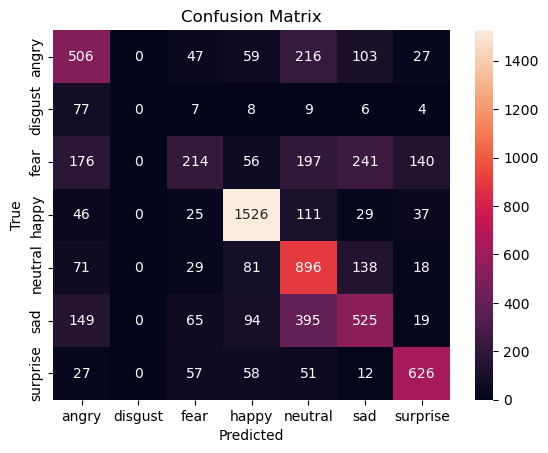

In [143]:
sns.heatmap(cm, annot=True , fmt='d',
           xticklabels=classes ,yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

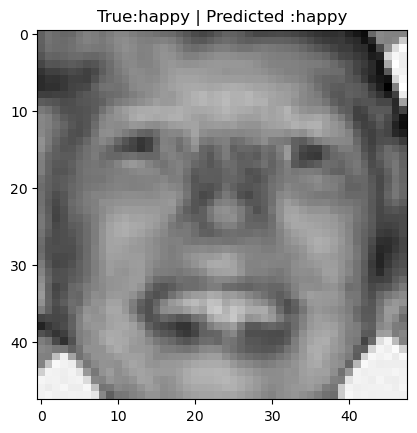

In [153]:
import random
# check results on a few select images
n = random.randint(0, len(test_labels) - 1)
orig_label = int(test_labels[n])
pred_label =  int(predictions[n])
is_correct = (orig_label==pred_label)
sample_img = all_test_images[n]
plt.imshow(sample_img[:,:,0], cmap='gray')
plt.title(f"True:{classes[orig_label]} | Predicted :{classes[pred_label]}")
plt.show()
